# Modeling Stellar Energy Transport

Numerical integration of the 1D stellar-interior equations for a Sun-like star,
with radiative + convective transport.  All physics lives in `stellar.py`;
this notebook is the driver that runs models, checks sanity, and produces plots.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from scipy.optimize import minimize

from stellar import TableInterpolator, StellarModel

# Solar constants (SI)
L_sun = 3.828e26;  R_sun = 6.957e8;  M_sun = 1.989e30;  rho_sun_avg = 1.408e3

def make_solar_model(X, Y, kappa, eps_tab, f_rho=1, f_T=1, f_R=1, f_L=1, f_P=None):
    rho0 = 1.42e-7 * rho_sun_avg * f_rho
    T0, R0, L0, M0 = 5770 * f_T, R_sun * f_R, L_sun * f_L, M_sun
    if f_P is not None:
        P0 = StellarModel(X, Y, kappa, eps_tab, M0=M0, R0=R0, L0=L0, T0=T0, rho0=rho0).P0 * f_P
        return StellarModel(X, Y, kappa, eps_tab, M0=M0, R0=R0, L0=L0, T0=T0, P0=P0)
    return StellarModel(X, Y, kappa, eps_tab, M0=M0, R0=R0, L0=L0, T0=T0, rho0=rho0)

def run_quick(X, Y, kappa, eps_tab, f_rho=1, f_T=1, f_R=1, f_L=1, f_P=None,
              eps_want=1e-3, max_steps=20000):
    try:
        m = make_solar_model(X, Y, kappa, eps_tab, f_rho=f_rho, f_T=f_T,
                             f_R=f_R, f_L=f_L, f_P=f_P)
        m.run(eps_want=eps_want, max_steps=max_steps)
        s = m.goal_summary()
        return dict(m=abs(s['m_frac']), r=abs(s['r_frac']), L=abs(s['L_frac']),
                    worst=max(abs(s['m_frac']), abs(s['r_frac']), abs(s['L_frac'])),
                    valid=s['stop'] in StellarModel.clean_stops)
    except Exception:
        return dict(m=1.0, r=1.0, L=1.0, worst=10.0, valid=False)

mpl.rcParams.update({
    'figure.dpi': 110, 'savefig.dpi': 300, 'savefig.bbox': 'tight',
    'font.size': 11, 'axes.titlesize': 12, 'axes.labelsize': 11,
    'axes.facecolor': 'whitesmoke', 'axes.grid': False,
    'axes.spines.top': False, 'axes.spines.right': False,
    'legend.frameon': False,
})

# Sanity-check toggle
RUN_SANITY = True

## Tasks 1–3: Interpolation tables, EOS, and composition

`TableInterpolator` handles the load -> bilinear-spline -> unit-convert
pipeline for both opacity and epsilon in one class.  `StellarModel`
bundles composition, EOS, integration, and plotting.

In [2]:
kappa   = TableInterpolator('opacity.txt',  si_factor=0.1,  name='opacity')
eps_tab = TableInterpolator('epsilon.txt',   si_factor=1e-4, name='epsilon')

## Task 6: Sanity checks

In [3]:
OPACITY_SANITY = [
    (3.750, -6.00, 2.84e-3), (3.755, -5.95, 3.11e-3), (3.755, -5.80, 2.68e-3),
    (3.755, -5.70, 2.46e-3), (3.755, -5.55, 2.12e-3), (3.770, -5.95, 4.70e-3),
    (3.780, -5.95, 6.25e-3), (3.795, -5.95, 9.45e-3), (3.770, -5.80, 4.05e-3),
    (3.775, -5.75, 4.43e-3), (3.780, -5.70, 4.94e-3), (3.795, -5.55, 6.89e-3),
    (3.800, -5.50, 7.69e-3),
]
EPSILON_SANITY = [
    (3.750, -6.00, 1.012e-92),
    (3.755, -5.95, 2.415e-92),
]

if RUN_SANITY:
    kappa.check(OPACITY_SANITY)
    print()
    eps_tab.check(EPSILON_SANITY)
else:
    print('Sanity checks skipped (RUN_SANITY = False).')

  logT   logR    expected SI    computed SI   rel.err
 3.750  -6.00      2.840e-03      2.844e-03     0.16%
 3.755  -5.95      3.110e-03      3.111e-03     0.03%
 3.755  -5.80      2.680e-03      2.692e-03     0.46%
 3.755  -5.70      2.460e-03      2.445e-03     0.61%
 3.755  -5.55      2.120e-03      2.116e-03     0.19%
 3.770  -5.95      4.700e-03      4.718e-03     0.37%
 3.780  -5.95      6.250e-03      6.227e-03     0.37%
 3.795  -5.95      9.450e-03      9.443e-03     0.07%
 3.770  -5.80      4.050e-03      4.124e-03     1.82%
 3.775  -5.75      4.430e-03      4.550e-03     2.71%
 3.780  -5.70      4.940e-03      5.031e-03     1.85%
 3.795  -5.55      6.890e-03      6.894e-03     0.06%
 3.800  -5.50      7.690e-03      7.691e-03     0.02%
opacity: passed

  logT   logR    expected SI    computed SI   rel.err
 3.750  -6.00      1.012e-92      1.012e-92     0.04%
 3.755  -5.95      2.415e-92      2.385e-92     1.24%
epsilon: passed


## Default run

stopped after 106 steps: mass exhausted
{'m_frac': np.float64(8.800538763887514e-09), 'r_frac': np.float64(0.06788279245115596), 'L_frac': np.float64(0.09571809127448526), 'core_outer': np.float64(0.24756861610833908), 'conv_width': np.float64(0.008947654070565289), 'stop': 'mass exhausted'}


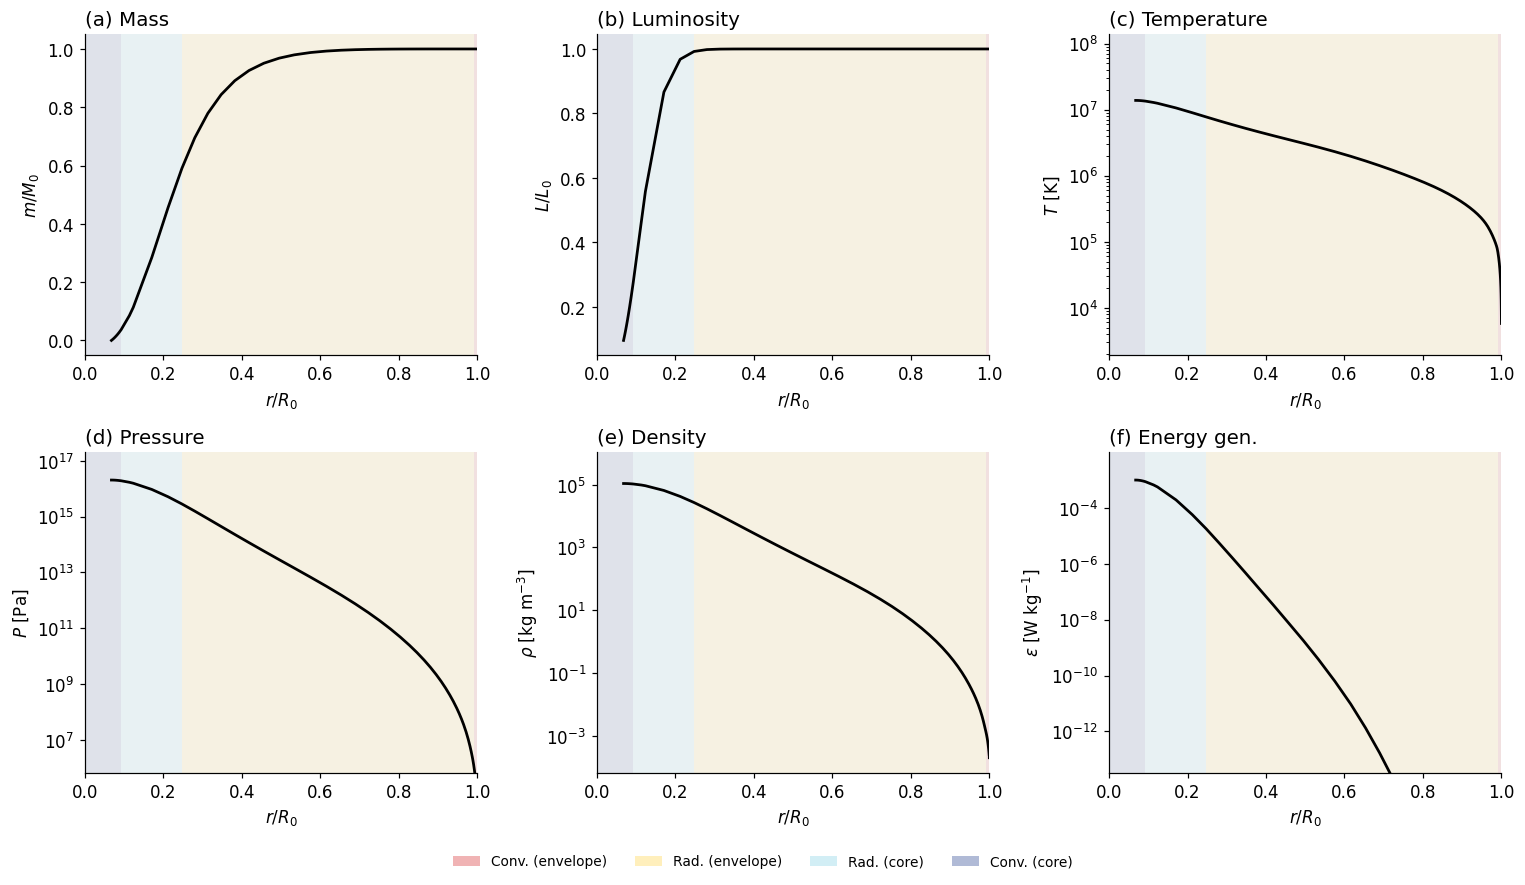

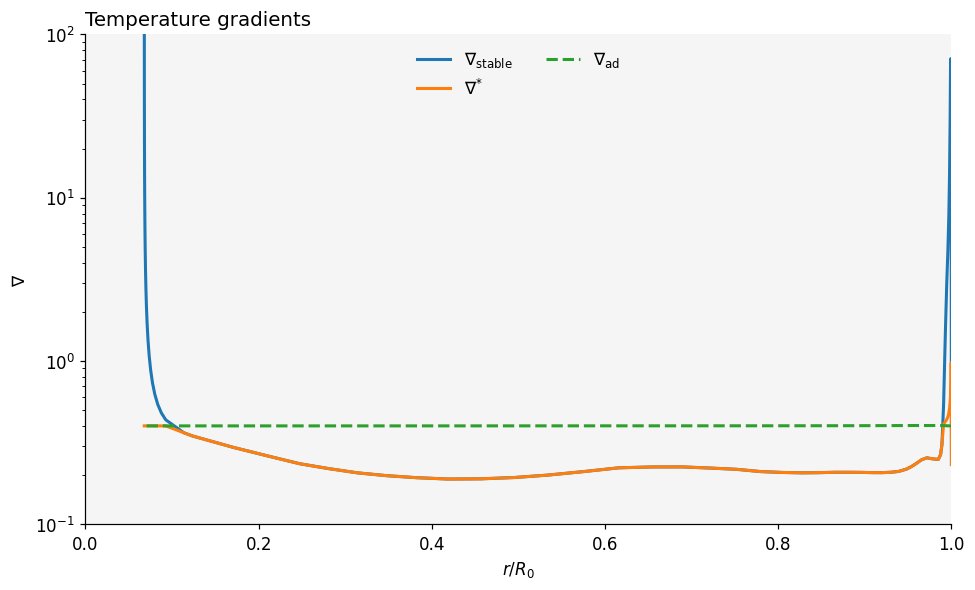

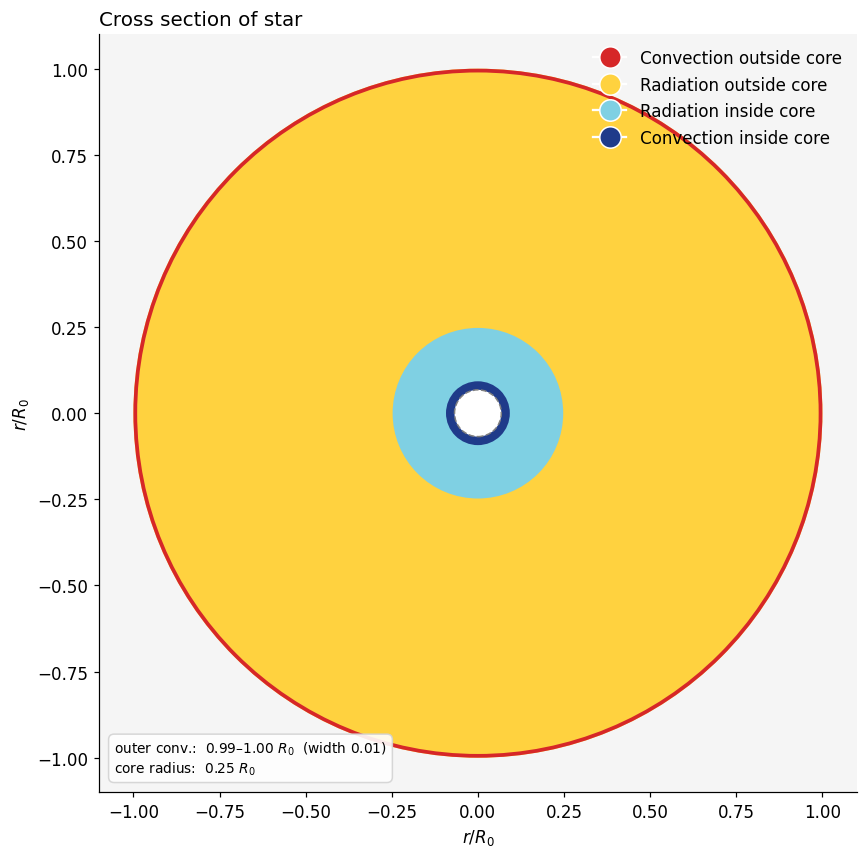

In [6]:
X = 0.7
Y = 0.29

default = make_solar_model(X, Y, kappa, eps_tab).run(verbose=True)
print(default.goal_summary())
default.plot_all(prefix='fig')

## Task 7: Parameter exploration

The brief says $\rho_0$ and $P_0$ may vary by orders of magnitude;
the other four parameters stay within a factor of 5.

In [7]:
trials = [
    ('default',           dict()),
    ('rho x 10',          dict(f_rho=10)),
    ('rho x 100',         dict(f_rho=100)),
    ('rho x 1000',        dict(f_rho=1000)),
    ('rho x100, P x10',   dict(f_rho=100, f_P=10)),
    ('R 0.7, rho x100',   dict(f_R=0.7, f_rho=100)),
    ('T x1.5, rho x100',  dict(f_T=1.5, f_rho=100)),
    ('T x0.7, rho x100',  dict(f_T=0.7, f_rho=100)),
    ('L x0.5, rho x100',  dict(f_L=0.5, f_rho=100)),
    ('L x2,   rho x100',  dict(f_L=2.0, f_rho=100)),
    ('L x4,   rho x100',  dict(f_L=4.0, f_rho=100)),
]

print(f"{'name':<22}{'m_f':>8}{'r_f':>8}{'L_f':>8}{'core':>8}{'conv':>8}  stop")
for name, kw in trials:
    try:
        m = make_solar_model(X, Y, kappa, eps_tab, **kw).run(eps_want=1e-3, max_steps=20000)
        s = m.goal_summary()
        print(f'{name:<22}{s["m_frac"]:8.3f}{s["r_frac"]:8.3f}{s["L_frac"]:8.3f}'
              f'{s["core_outer"]:8.3f}{s["conv_width"]:8.3f}  {s["stop"]}')
    except Exception as e:
        print(f'{name:<22}  FAILED: {e}')

name                       m_f     r_f     L_f    core    conv  stop
default                  0.000   0.068   0.096   0.248   0.009  mass exhausted
rho x 10                 0.000   0.061   0.268   0.235   0.060  mass exhausted
rho x 100                0.008   0.000  -0.308   0.254   0.198  reached zero
rho x 1000               0.000   0.205   0.999   0.000   0.795  mass exhausted
rho x100, P x10          0.000   0.205   0.999   0.000   0.795  mass exhausted
R 0.7, rho x100          0.040   0.137  -0.182   0.323   0.143  reached zero
T x1.5, rho x100         0.000   0.000   0.542   0.246   0.169  centre reached
T x0.7, rho x100         0.016   0.001  -0.082   0.231   0.243  reached zero
L x0.5, rho x100         0.000   0.118   0.882   0.260   0.165  mass exhausted
L x2,   rho x100         0.053   0.022  -0.058   0.210   0.239  reached zero
L x4,   rho x100         0.145   0.055  -0.100   0.184   0.243  reached zero


### Optimising $(f_\rho, f_T)$ via 2D Nelder-Mead

We minimise the worst goal metric over both $f_\rho$ and $f_T$
simultaneously using `scipy.optimize.minimize` with the Nelder-Mead simplex.

In [8]:
def worst_metric(params):
    frho, fT = params
    d = run_quick(X, Y, kappa, eps_tab, f_rho=frho, f_T=fT,
                  eps_want=1e-5, max_steps=50000)
    return d['worst'] if d['valid'] else 10.0

result = minimize(worst_metric, [97.5, 1.182], method='Nelder-Mead',
                  options={'xatol': 0.1, 'fatol': 1e-5, 'maxiter': 200,
                           'adaptive': True})
frho_opt, fT_opt = result.x
print(f'f_rho = {frho_opt:.3f}, f_T = {fT_opt:.4f}, worst = {result.fun:.4e}')

f_rho = 99.938, f_T = 1.1229, worst = 1.6070e-02


### Best-fit model

In [ ]:
best = make_solar_model(X, Y, kappa, eps_tab, f_rho=frho_opt, f_T=fT_opt)
best.run(eps_want=1e-5, max_steps=50000, verbose=True)

s = best.goal_summary()
print(f'm_f = {s["m_frac"]:.4e},  r_f = {s["r_frac"]:.4e},  L_f = {s["L_frac"]:.4e}')
print(f'core = {s["core_outer"]:.3f} R0,  conv = {s["conv_width"]:.3f} R0')
best.plot_all(prefix='fig_best')

stopped after 174 steps: reached zero
m_f = 5.5828e-03,  r_f = 1.4007e-04,  L_f = -1.6070e-02
core = 0.252 R0,  conv = 0.205 R0


## Parameter-space sweep

Two-panel summary:
- **(a)** 1D sweep of goal metrics vs $f_\rho$.
- **(b)** 2D worst-goal contour over $(f_\rho, f_T)$.

In [ ]:
from matplotlib.gridspec import GridSpec

frho_arr = np.logspace(0, 3, 16)
fT_arr   = np.linspace(0.5, 2.0, 12)

# Panel (a): 1D sweep over f_rho
line_runs = [run_quick(X, Y, kappa, eps_tab, f_rho=f) for f in frho_arr]
m_line = np.array([d['m'] for d in line_runs])
r_line = np.array([d['r'] for d in line_runs])
L_line = np.array([d['L'] for d in line_runs])
valid_line = np.array([d['valid'] for d in line_runs])

# Panel (b): 2D sweep over (f_rho, f_T)
worst_2d  = np.full((len(fT_arr), len(frho_arr)), np.nan)
valid_2d  = np.zeros_like(worst_2d, dtype=bool)
for i, fT in enumerate(fT_arr):
    for j, frho in enumerate(frho_arr):
        d = run_quick(X, Y, kappa, eps_tab, f_T=fT, f_rho=frho)
        worst_2d[i, j] = d['worst']
        valid_2d[i, j] = d['valid']

wv = np.where(valid_2d, worst_2d, np.inf)
ij = np.unravel_index(np.argmin(wv), worst_2d.shape)
fT_best, frho_best = fT_arr[ij[0]], frho_arr[ij[1]]
print(f'best grid point: frho={frho_best:.1f}, fT={fT_best:.3f}, '
      f'worst={worst_2d[ij]:.4f}')

# ── Plot ──
fig = plt.figure(figsize=(14, 5))
gs = GridSpec(1, 2, width_ratios=[1, 1.25], figure=fig, wspace=0.28)

ax1 = fig.add_subplot(gs[0])
for arr, lbl, col in [(m_line, r'$m/M_0$', '#1f77b4'),
                      (r_line, r'$r/R_0$', '#2ca02c'),
                      (L_line, r'$L/L_0$', '#d62728')]:
    a = arr.astype(float).copy(); a[~valid_line] = np.nan
    ax1.semilogx(frho_arr, a, marker='o', lw=1.8, color=col, label=lbl)
ax1.axhline(0.05, color='gray', lw=1, ls='--', alpha=0.7, label='5% goal')
for arr in (m_line, r_line, L_line):
    ax1.scatter(frho_arr[~valid_line], arr[~valid_line],
                marker='x', color='k', s=40, zorder=5)
ax1.set_ylim(-0.02, 1.05)
ax1.set_xlabel(r'$\rho_0$ multiplier $f_\rho$')
ax1.set_ylabel('|final / initial|')
ax1.set_title(r'(a) Goal metrics vs $f_\rho$', loc='left', fontsize=13)
ax1.legend(loc='center left')

ax2 = fig.add_subplot(gs[1])
FRHO, FT = np.meshgrid(frho_arr, fT_arr)
W = np.where(valid_2d, worst_2d, np.nan)
cf = ax2.contourf(FRHO, FT, W, levels=np.linspace(0, 1, 21),
                  cmap='plasma', extend='max')
ax2.contourf(FRHO, FT, valid_2d.astype(float), levels=[-0.5, 0.5],
             colors='none', hatches=['////'])
ax2.contourf(FRHO, FT, valid_2d.astype(float), levels=[-0.5, 0.5],
             colors=['#555555'], alpha=0.35)
if np.nanmin(W) < 0.05:
    ax2.contour(FRHO, FT, np.where(np.isnan(W), 1.0, W),
                levels=[0.05], colors='cyan', linewidths=2)
cs = ax2.contour(FRHO, FT, W, levels=[0.1, 0.2, 0.4, 0.6, 0.8],
                 colors='black', linewidths=0.6, alpha=0.7)
ax2.clabel(cs, inline=True, fontsize=8, fmt='%.2f')
ax2.plot(frho_best, fT_best, '*', ms=20, mfc='white', mec='black', zorder=10,
         label=f'sweep best ({frho_best:.0f}, {fT_best:.2f})')
ax2.plot(frho_opt, fT_opt, 'o', ms=10, mfc='#00ffff', mec='black', zorder=11,
         label=f'optimised ({frho_opt:.0f}, {fT_opt:.2f})')
ax2.set_xscale('log')
ax2.set_xlabel(r'$f_\rho$')
ax2.set_ylabel(r'$f_T$')
ax2.set_title('(b) Worst-goal map (hatched = collapse)', loc='left', fontsize=13)
ax2.legend(loc='lower left', fontsize=9)
fig.colorbar(cf, ax=ax2, label=r'max($|m_f|$, $|r_f|$, $|L_f|$)')
fig.savefig('fig_parameter_sweep.png')
plt.show()

## Interpolation order: bilinear vs bicubic

Compare the relative error of bilinear ($k_x = k_y = 1$) and bicubic
($k_x = k_y = 3$) interpolation against the opacity sanity-check rows.

In [ ]:
kappa_cub = TableInterpolator('opacity.txt', si_factor=0.1, name='opacity',
                              kx=3, ky=3)

labels, err_lin, err_cub = [], [], []
for logT, logR, expected in OPACITY_SANITY:
    T   = 10 ** logT
    rho = 10 ** logR * (T / 1e6) ** 3 * 1e3
    labels.append(f'({logT:.3f}, {logR:.2f})')
    err_lin.append(abs(kappa(T, rho, warn=False)     - expected) / expected * 100)
    err_cub.append(abs(kappa_cub(T, rho, warn=False) - expected) / expected * 100)

ix, w = np.arange(len(labels)), 0.35
fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(ix - w/2, err_lin, w, label='Bilinear', color='#1f77b4')
ax.bar(ix + w/2, err_cub, w, label='Bicubic',  color='#d62728')
ax.axhline(5.0, color='gray', ls='--', lw=1.2, label='5% threshold')
ax.set_xticks(ix)
ax.set_xticklabels(labels, rotation=55, ha='right', fontsize=8)
ax.set(xlabel=r'Sanity row ($\log T$, $\log R$)', ylabel='Relative error [%]',
       ylim=(0, max(max(err_cub), 5.5) * 1.15))
ax.set_title('Opacity interpolation error: bilinear vs bicubic',
             loc='left', fontsize=13)
ax.legend()
fig.tight_layout()
fig.savefig('fig_interp_error.png')
plt.show()